# Notebook Demonstrativo v2 — `cProfile` e `snakeviz` com Imagens Reais

Esta é a versão 2 do notebook didático de profiling, agora usando **imagens reais** dos datasets da disciplina:

- **fingerprints** (impressões digitais)
- **faces**

## Objetivos
Ao final deste notebook, o aluno deve conseguir:

1. aplicar `cProfile` em um pipeline real com imagens;
2. salvar e inspecionar arquivos `.prof`;
3. interpretar estatísticas com `pstats`;
4. abrir o resultado no `snakeviz`;
5. identificar hotspots de:
   - leitura de imagem,
   - pré-processamento,
   - extração de características,
   - escrita em disco;
6. validar se uma otimização realmente melhorou o desempenho.

## Fluxo da aula
```text
Carregar imagens reais -> rodar pipeline -> perfilar com cProfile ->
salvar .prof -> analisar com pstats -> abrir no snakeviz ->
otimizar -> comparar
```

> Ideia central: **não otimizar antes de medir**.


## 1. Contexto desta versão

Aqui vamos perfilar dois pipelines reais e simples:

### Pipeline A — fingerprints
- ler imagem em tons de cinza;
- aplicar `CLAHE`;
- equalização;
- blur;
- salvar resultado final em disco.

### Pipeline B — faces
- ler imagem;
- redimensionar;
- aplicar transformações pesadas;
- extrair vetor de características.

Esses dois fluxos são bons para profiling porque combinam:
- **I/O**;
- **operações de imagem**;
- **loops repetidos**;
- **custos diferentes por tipo de dado**.


In [1]:

from __future__ import annotations

import os
import io
import time
import random
import shutil
import cProfile
import pstats
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str

RNG = np.random.default_rng(42)
random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


## 2. Diretórios dos datasets

Os caminhos abaixo apontam para os datasets reais usados na disciplina.


In [2]:

DIGITAIS_DIR = Path("/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/digitais")
FACES_DIR = Path("/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/faces")

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

PROFILE_DIR = Path("./profiles_demo_reais")
PROFILE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("./saida_demo_reais")
OUTPUT_FP_DIR = OUTPUT_DIR / "fingerprints"
OUTPUT_FP_DIR.mkdir(parents=True, exist_ok=True)

print("DIGITAIS_DIR existe?", DIGITAIS_DIR.exists(), "-", DIGITAIS_DIR)
print("FACES_DIR existe?", FACES_DIR.exists(), "-", FACES_DIR)
print("Diretório dos perfis:", PROFILE_DIR.resolve())
print("Diretório de saída:", OUTPUT_FP_DIR.resolve())


DIGITAIS_DIR existe? True - /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/digitais
FACES_DIR existe? True - /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/faces
Diretório dos perfis: /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/M3A2/profiles_demo_reais
Diretório de saída: /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/M3A2/saida_demo_reais/fingerprints


## 3. Funções utilitárias


In [14]:

def list_image_files(folder: Path, limit: int | None = None) -> list[Path]:
    files = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    files = sorted(files)
    if limit is not None:
        files = files[:limit]
    return files

def load_gray(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Não foi possível ler {path}")
    return img

def show_image(img: np.ndarray, title: str = ""):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def summarize_paths(paths: list[Path], label: str) -> pd.DataFrame:
    rows = []
    for p in paths:
        try:
            img = load_gray(p)
            rows.append({
                "dataset": label,
                "file": p.name,
                "height": img.shape[0],
                "width": img.shape[1],
                "pixels": img.size
            })
        except Exception:
            pass
    return pd.DataFrame(rows)


def reset_output_dir():
    OUTPUT_FP_DIR.mkdir(parents=True, exist_ok=True)

    for f in OUTPUT_FP_DIR.glob("*"):
        try:
            if f.is_file():
                f.unlink()
        except Exception as e:
            print("Aviso:", f, e)   


## 4. Seleção de amostras reais

Vamos trabalhar com uma quantidade moderada de imagens para manter o notebook interativo e didático.


In [4]:

N_FP = 24
N_FACES = 24

fp_paths = list_image_files(DIGITAIS_DIR, limit=N_FP)
face_paths = list_image_files(FACES_DIR, limit=N_FACES)

print("Fingerprints encontrados:", len(fp_paths))
print("Faces encontradas:", len(face_paths))

if len(fp_paths) == 0 and len(face_paths) == 0:
    raise RuntimeError(
        "Nenhuma imagem foi encontrada. Verifique os paths DIGITAIS_DIR e FACES_DIR "
        "e se o ambiente atual enxerga /mnt/c."
    )


Fingerprints encontrados: 24
Faces encontradas: 24


In [5]:

meta_fp = summarize_paths(fp_paths, "fingerprint")
meta_face = summarize_paths(face_paths, "face")

meta = pd.concat([meta_fp, meta_face], ignore_index=True)
display(meta.groupby("dataset")[["height", "width", "pixels"]].agg(["count", "mean", "min", "max"]))
display(meta.head())


height                  width                  pixels            \
             count   mean  min  max count   mean  min  max  count      mean   
dataset                                                                       
face            24  512.0  512  512    24  512.0  512  512     24  262144.0   
fingerprint     24  492.0  492  492    24  351.0  351  351     24  172692.0   

                             
                min     max  
dataset                      
face         262144  262144  
fingerprint  172692  172692

,dataset,file,height,width,pixels
0,fingerprint,001.bmp,492,351,172692
1,fingerprint,002.bmp,492,351,172692
2,fingerprint,003.bmp,492,351,172692
3,fingerprint,004.bmp,492,351,172692
4,fingerprint,005.bmp,492,351,172692


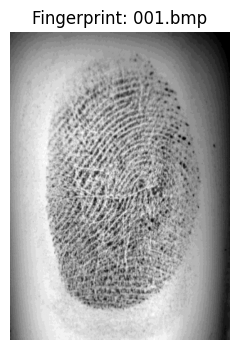

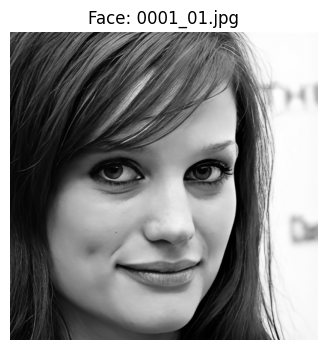

In [6]:

if fp_paths:
    show_image(load_gray(fp_paths[0]), f"Fingerprint: {fp_paths[0].name}")

if face_paths:
    show_image(load_gray(face_paths[0]), f"Face: {face_paths[0].name}")


## 5. Pipeline real para fingerprints

Este pipeline é simples o suficiente para ensinar, mas já possui custo observável:

1. leitura da imagem;
2. `CLAHE`;
3. equalização;
4. blur;
5. escrita em disco.

Esse pipeline é excelente para discutir um ponto central de profiling:
> o gargalo pode estar tanto em **processamento** quanto em **I/O**.


In [7]:

def fingerprint_pipeline(path: Path, out_dir: Path, save: bool = True) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    x = clahe.apply(img)
    x = cv2.equalizeHist(x)
    x = cv2.GaussianBlur(x, (5, 5), sigmaX=1.2)

    out_path = ""
    if save:
        out_file = out_dir / f"{path.stem}_fp_demo.png"
        cv2.imwrite(str(out_file), x)
        out_path = str(out_file)

    return {
        "kind": "fingerprint",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "saved": save,
        "out_path": out_path
    }


## 6. Pipeline real para faces

Aqui vamos usar um fluxo mais computacional:

1. leitura;
2. resize;
3. transformações matemáticas repetidas;
4. histograma;
5. vetor de características.

Esse pipeline é bom para destacar hotspots puramente computacionais.


In [8]:

def face_feature_pipeline(path: Path) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path).astype(np.float32) / 255.0
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)

    x = img.copy()
    for _ in range(4):
        x = np.tanh(x)
        x = np.sqrt(np.abs(x) + 1e-8)
        x = np.sin(x) + np.cos(x)

    hist, _ = np.histogram(x.ravel(), bins=24, range=(x.min(), x.max() + 1e-8))
    hist = hist.astype(np.float64)
    hist /= hist.sum() + 1e-8

    row_proj = x.mean(axis=1)
    col_proj = x.mean(axis=0)
    feat = np.concatenate([hist, row_proj[:24], col_proj[:24]])

    return {
        "kind": "face",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "feature_dim": int(feat.shape[0])
    }



def face_feature_pipeline(path: Path) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path).astype(np.float32) / 255.0
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)

    x = img.copy()
    for _ in range(4):
        x = np.tanh(x)
        x = np.sqrt(np.abs(x) + 1e-8)
        x = np.sin(x) + np.cos(x)

    flat = x.ravel().astype(np.float64)
    xmin = float(np.min(flat))
    xmax = float(np.max(flat))
    if not np.isfinite(xmin) or not np.isfinite(xmax):
        flat = np.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)
        xmin = float(np.min(flat))
        xmax = float(np.max(flat))

    # Evita range degenerado, que quebra o np.histogram
    if abs(xmax - xmin) < 1e-12:
        hist = np.zeros(24, dtype=np.float64)
        hist[0] = 1.0
    else:
        hist, _ = np.histogram(flat, bins=24, range=(xmin, xmax))
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-8

    row_proj = x.mean(axis=1)
    col_proj = x.mean(axis=0)
    feat = np.concatenate([hist, row_proj[:24], col_proj[:24]])

    return {
        "kind": "face",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "feature_dim": int(feat.shape[0])
    }


In [9]:

tasks = (
    [{"kind": "fingerprint", "path": p} for p in fp_paths] +
    [{"kind": "face", "path": p} for p in face_paths]
)

summary_tasks = pd.DataFrame({
    "kind": [t["kind"] for t in tasks],
    "file": [t["path"].name for t in tasks]
})
display(summary_tasks["kind"].value_counts())
display(summary_tasks.head())


kind
fingerprint    24
face           24
Name: count, dtype: int64

,kind,file
0,fingerprint,001.bmp
1,fingerprint,002.bmp
2,fingerprint,003.bmp
3,fingerprint,004.bmp
4,fingerprint,005.bmp


In [10]:

def mixed_pipeline(tasks: list[dict], save_fingerprints: bool = True) -> pd.DataFrame:
    rows = []
    for task in tasks:
        if task["kind"] == "fingerprint":
            rows.append(fingerprint_pipeline(task["path"], OUTPUT_FP_DIR, save=save_fingerprints))
        else:
            rows.append(face_feature_pipeline(task["path"]))
    return pd.DataFrame(rows)


## 8. Execução normal do pipeline

Antes do profiling, vamos simplesmente medir o pipeline misto.


In [11]:

reset_output_dir()

t0 = time.perf_counter()
df_baseline = mixed_pipeline(tasks, save_fingerprints=True)
baseline_time = time.perf_counter() - t0

print(f"Tempo total do pipeline misto: {baseline_time:.3f} s")
display(df_baseline.groupby("kind")[["task_time_s"]].agg(["count", "mean", "min", "max"]))


Tempo total do pipeline misto: 0.917 s


task_time_s                             
                  count      mean      min       max
kind                                                
face                 24  0.011279  0.00707  0.020791
fingerprint          24  0.026883  0.01690  0.043455

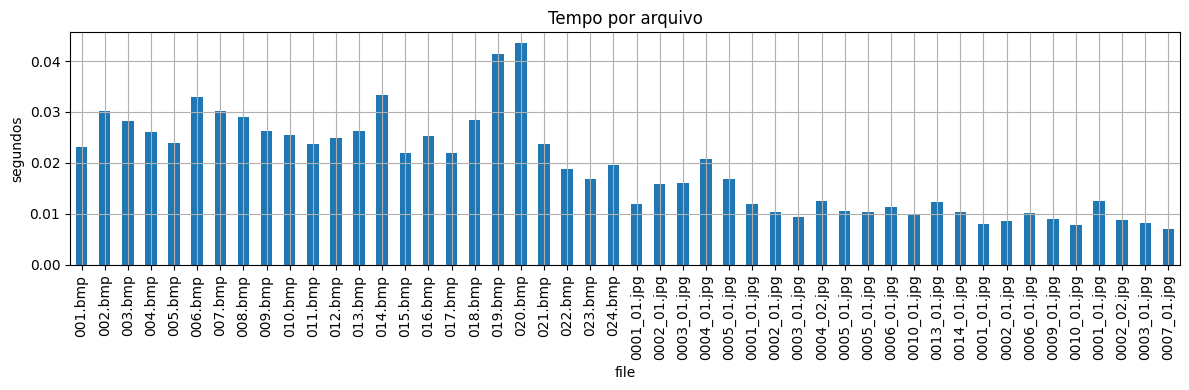

In [12]:

ax = df_baseline.plot.bar(x="file", y="task_time_s", figsize=(12, 4), legend=False, title="Tempo por arquivo")
ax.set_ylabel("segundos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



def fingerprint_pipeline_fast(path: Path, out_dir: Path, save: bool = False) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    x = clahe.apply(img)
    x = cv2.equalizeHist(x)
    x = cv2.GaussianBlur(x, (5, 5), sigmaX=1.2)

    if save:
        out_file = out_dir / f"{path.stem}_fp_fast.png"
        cv2.imwrite(str(out_file), x)

    return {
        "kind": "fingerprint",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "saved": save
    }

def face_feature_pipeline_fast(path: Path) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path).astype(np.float32) / 255.0
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)

    x = img.copy()
    for _ in range(2):
        x = np.tanh(x)
        x = np.sqrt(np.abs(x) + 1e-8)
        x = np.sin(x) + np.cos(x)

    flat = x.ravel().astype(np.float64)
    xmin = float(np.min(flat))
    xmax = float(np.max(flat))
    if not np.isfinite(xmin) or not np.isfinite(xmax):
        flat = np.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)
        xmin = float(np.min(flat))
        xmax = float(np.max(flat))

    if abs(xmax - xmin) < 1e-12:
        hist = np.zeros(24, dtype=np.float64)
        hist[0] = 1.0
    else:
        hist, _ = np.histogram(flat, bins=24, range=(xmin, xmax))
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-8

    row_proj = x.mean(axis=1)
    col_proj = x.mean(axis=0)
    feat = np.concatenate([hist, row_proj[:24], col_proj[:24]])

    return {
        "kind": "face",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "feature_dim": int(feat.shape[0])
    }

def mixed_pipeline_fast(tasks: list[dict], save_fingerprints: bool = False) -> pd.DataFrame:
    rows = []
    for task in tasks:
        if task["kind"] == "fingerprint":
            rows.append(fingerprint_pipeline_fast(task["path"], OUTPUT_FP_DIR, save=save_fingerprints))
        else:
            rows.append(face_feature_pipeline_fast(task["path"]))
    return pd.DataFrame(rows)


In [15]:

prof = cProfile.Profile()

reset_output_dir()

prof.enable()
_ = mixed_pipeline(tasks, save_fingerprints=True)
prof.disable()

print("Profiling concluído.")


Profiling concluído.


## 10. Leitura textual com `pstats`

Vamos começar ordenando por **tempo acumulado** (`cumulative`).


In [16]:

stats = pstats.Stats(prof).sort_stats("cumulative")
stats.print_stats(20)


         4177 function calls (4167 primitive calls) in 1.054 seconds

   Ordered by: cumulative time
   List reduced from 206 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    1.054    0.527 /home/chaul/hpc_gpu/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    1.054    0.527 {built-in method builtins.exec}
        1    0.000    0.000    1.054    1.054 /tmp/ipykernel_2477/1678886153.py:1(<module>)
        1    0.001    0.001    1.054    1.054 /tmp/ipykernel_2477/3832805303.py:1(mixed_pipeline)
       24    0.001    0.000    0.695    0.029 /tmp/ipykernel_2477/3028057412.py:1(fingerprint_pipeline)
       48    0.000    0.000    0.635    0.013 /tmp/ipykernel_2477/1974918297.py:8(load_gray)
       48    0.634    0.013    0.634    0.013 {imread}
       24    0.380    0.016    0.380    0.016 {imwrite}
       24    0.011    0.000    0.357    0.015 /tmp/i

## 11. Salvando o arquivo `.prof`

Esse arquivo será usado pelo `snakeviz`.


In [17]:

profile_path = PROFILE_DIR / "pipeline_misto_reais.prof"
prof.dump_stats(str(profile_path))

print("Arquivo salvo em:")
print(profile_path.resolve())


Arquivo salvo em:
/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/M3A2/profiles_demo_reais/pipeline_misto_reais.prof


## 12. Observando por `tottime` vs `cumtime`

Essa comparação é muito importante em sala.

### Relembrando
- `tottime` = tempo da função em si;
- `cumtime` = tempo da função + tempo das funções que ela chamou.


In [ ]:

print("Top 15 por cumulative")
pstats.Stats(str(profile_path)).sort_stats("cumulative").print_stats(15)

print("\nTop 15 por tottime")
pstats.Stats(str(profile_path)).sort_stats("tottime").print_stats(15)


## 13. Como interpretar este primeiro perfil

Tente responder:

1. O maior custo está em leitura, escrita ou processamento?
2. Fingerprints e faces têm custos parecidos?
3. A escrita em disco pesa visivelmente?
4. Alguma função “pai” domina o tempo acumulado?
5. O hotspot principal vem do OpenCV, do NumPy ou da lógica Python?


## 14. Criando uma versão melhorada

Agora vamos construir uma segunda versão para comparação.  
As melhorias serão simples e pedagógicas:

- fingerprints:
  - manter pipeline semelhante;
  - **desativar salvamento** para medir impacto de I/O;
- faces:
  - reduzir um pouco o custo computacional;
  - manter a mesma lógica geral.


In [ ]:

def fingerprint_pipeline_fast(path: Path, out_dir: Path, save: bool = False) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    x = clahe.apply(img)
    x = cv2.equalizeHist(x)
    x = cv2.GaussianBlur(x, (5, 5), sigmaX=1.2)

    if save:
        out_file = out_dir / f"{path.stem}_fp_fast.png"
        cv2.imwrite(str(out_file), x)

    return {
        "kind": "fingerprint",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "saved": save
    }

def face_feature_pipeline_fast(path: Path) -> dict:
    t0 = time.perf_counter()

    img = load_gray(path).astype(np.float32) / 255.0
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)

    x = img.copy()
    for _ in range(2):
        x = np.tanh(x)
        x = np.sqrt(np.abs(x) + 1e-8)
        x = np.sin(x) + np.cos(x)

    hist, _ = np.histogram(x.ravel(), bins=24, range=(x.min(), x.max() + 1e-8))
    hist = hist.astype(np.float64)
    hist /= hist.sum() + 1e-8

    row_proj = x.mean(axis=1)
    col_proj = x.mean(axis=0)
    feat = np.concatenate([hist, row_proj[:24], col_proj[:24]])

    return {
        "kind": "face",
        "file": path.name,
        "task_time_s": time.perf_counter() - t0,
        "feature_dim": int(feat.shape[0])
    }

def mixed_pipeline_fast(tasks: list[dict], save_fingerprints: bool = False) -> pd.DataFrame:
    rows = []
    for task in tasks:
        if task["kind"] == "fingerprint":
            rows.append(fingerprint_pipeline_fast(task["path"], OUTPUT_FP_DIR, save=save_fingerprints))
        else:
            rows.append(face_feature_pipeline_fast(task["path"]))
    return pd.DataFrame(rows)


In [ ]:

reset_output_dir()

t0 = time.perf_counter()
df_fast = mixed_pipeline_fast(tasks, save_fingerprints=False)
fast_time = time.perf_counter() - t0

comparison = pd.DataFrame({
    "versao": ["baseline_reais", "melhorada_reais"],
    "tempo_total_s": [baseline_time, fast_time]
})
comparison["speedup"] = baseline_time / comparison["tempo_total_s"]

display(comparison)


## 15. Profiling da versão melhorada

Agora repetimos o processo para gerar um segundo `.prof`.


In [ ]:

prof_fast = cProfile.Profile()

reset_output_dir()

prof_fast.enable()
_ = mixed_pipeline_fast(tasks, save_fingerprints=False)
prof_fast.disable()

profile_fast_path = PROFILE_DIR / "pipeline_misto_reais_fast.prof"
prof_fast.dump_stats(str(profile_fast_path))

print("Perfis gerados:")
for p in PROFILE_DIR.glob("*.prof"):
    print("-", p.name)


In [ ]:

print("Versão melhorada — top por cumulative")
pstats.Stats(str(profile_fast_path)).sort_stats("cumulative").print_stats(15)


## 16. O que deve mudar entre os dois perfis?

Peça aos alunos para verificar:

1. O peso da escrita em disco diminuiu?
2. O gargalo mudou de lugar?
3. A função dominante continua a mesma?
4. O ganho veio de:
   - menos I/O?
   - menos computação?
   - ambos?


## 17. `snakeviz`: visualização interativa

### O que é?
`snakeviz` é um visualizador para arquivos `.prof`.

### Como usar?
Depois de gerar os arquivos, abra no terminal:

```bash
snakeviz profiles_demo_reais/pipeline_misto_reais.prof
```

e depois:

```bash
snakeviz profiles_demo_reais/pipeline_misto_reais_fast.prof
```

### O que observar?
- qual função ocupa a maior área;
- qual árvore de chamadas leva até ela;
- como a área muda entre a versão baseline e a melhorada.


In [ ]:

def check_snakeviz():
    try:
        result = subprocess.run(["snakeviz", "--version"], capture_output=True, text=True, check=False)
        return result.returncode == 0, result.stdout.strip() or result.stderr.strip()
    except FileNotFoundError:
        return False, "snakeviz não encontrado no PATH."

ok, msg = check_snakeviz()
print("snakeviz disponível?", ok)
print(msg)


In [ ]:

print("Comandos sugeridos para o terminal:")
print(f"snakeviz {profile_path}")
print(f"snakeviz {profile_fast_path}")


## 18. Como explicar `snakeviz` para os alunos

### Estratégia didática
1. Abrir o perfil baseline;
2. pedir que identifiquem visualmente o maior bloco;
3. clicar nesse bloco;
4. navegar para as funções filhas;
5. repetir na versão melhorada.

### Perguntas orientadoras
- A otimização reduziu o maior bloco?
- A função crítica desapareceu ou só perdeu peso?
- O gargalo foi removido ou apenas deslocado?


## 19. Resumo: `cProfile` + `snakeviz`

| Ferramenta | Função |
|---|---|
| `cProfile` | coleta o perfil |
| `pstats` | lê e ordena as estatísticas |
| `snakeviz` | visualiza a árvore de chamadas |

### Regra prática
- use `cProfile` para medir;
- use `pstats` para leitura objetiva;
- use `snakeviz` para ensino e navegação visual.


## 20. Exercício guiado

### Parte A — coletar perfil
1. Rode o pipeline baseline.
2. Gere o `.prof`.
3. Liste os 10 maiores por `cumtime`.

### Parte B — interpretar
4. Identifique o hotspot principal.
5. Explique se ele vem de I/O ou computação.

### Parte C — melhorar
6. Desative escrita em disco para fingerprints.
7. Reduza o custo do pipeline de faces.
8. Gere novo `.prof`.

### Parte D — visualizar
9. Abra ambos no `snakeviz`.
10. Compare visualmente os perfis.


## 21. Desafios extras

1. Rodar profiling só com fingerprints.
2. Rodar profiling só com faces.
3. Aumentar `N_FP` e `N_FACES`.
4. Reativar escrita em disco e medir impacto.
5. Alterar o número de iterações do pipeline de faces.
6. Escrever um parágrafo final respondendo:

> “Se eu fosse otimizar este sistema de verdade, por onde começaria e por quê?”


In [ ]:

# Célula livre para experimentos
pass
